In [1]:
import Pkg
Pkg.activate("../..")

  Activating project at `~/.julia/dev/DiffusionEvolution`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

Precompiling DiffusionEvolution
  ✓ DiffusionEvolution
  1 dependency successfully precompiled in 5 seconds. 122 already precompiled.


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
d = 10
nsamples = 1000
T = 20

20

In [7]:
λ_diag = 0.1
λ_skew = 0.01
θ0 = fill(0.0, d)
θ1 = fill(5.0, d)
γ = 0.6
J, θ, min_eigv, max_eigv = random_pars(λ_diag, λ_skew, θ0, θ1, d=d);

In [8]:
min_eigv, max_eigv

(7.398731737571566, 23.250510865296)

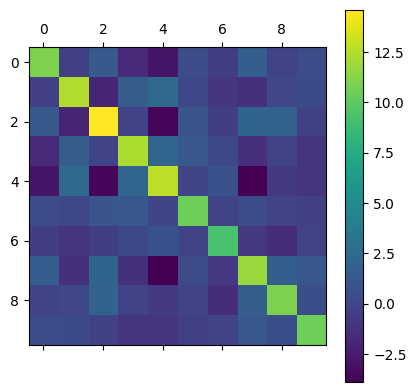

PyObject <matplotlib.colorbar.Colorbar object at 0x73d0e4aa9f90>

In [9]:
matshow(inv(J))
colorbar()

In [10]:
θ |> norm

17.403461792428967

In [11]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

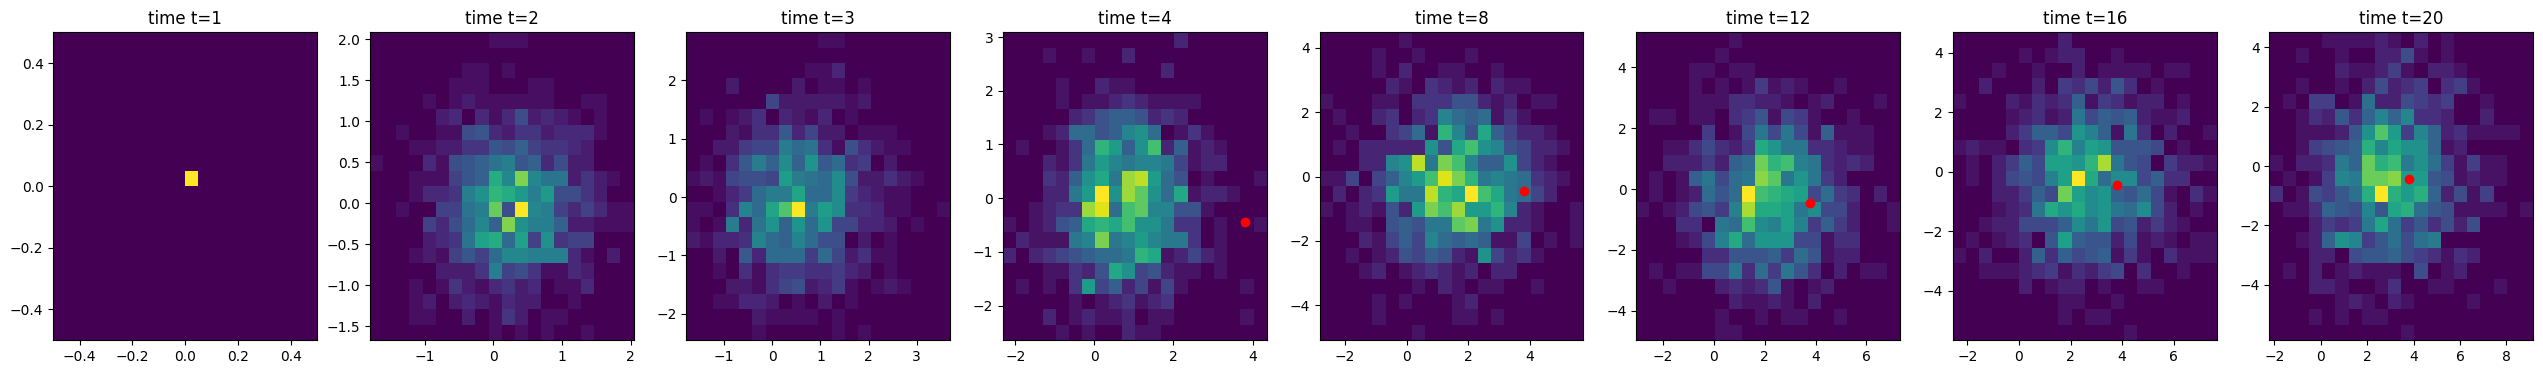

In [12]:
tpoints = [1,2,3,4,8,12,16,20]
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red")
    ax[t].set_title("time t=$(tpoints[t])")
end

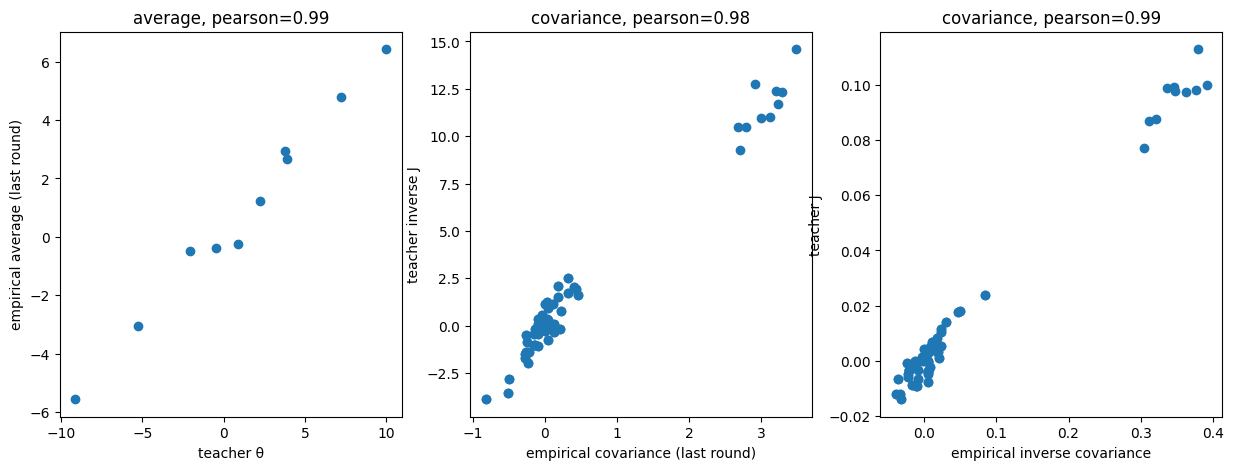

PyObject Text(0.5, 1.0, 'covariance, pearson=0.99')

In [13]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [63]:
t_sample=[1, 2, 3, 4, 5, 6]

6-element Vector{Int64}:
 1
 2
 3
 4
 5
 6

In [64]:
counts = ones(nsamples, length(t_sample)) ./ nsamples
deltas = [1,1,1,1,10]
data = collect_data(x[:,:,t_sample], counts, deltas);

In [55]:
l_values, x_opt, status = learn_nlopt(data, initialize=length(t_sample), λ=0.6, prior=0.01, ftol_rel=1e-7)

(7.52285564473964, [0.23864895316842935, -0.011995301664046353, 0.25809490630252957, 0.003924729742531118, 0.02334005457246291, 0.20998169623294574, 0.029875609511752454, -0.028026999933120113, -0.004649201879265593, 0.2157893684507452  …  2.2215247899210984, -0.25841831865135895, 1.887610170373401, -0.31174873958407234, 3.4961622505131125, 4.698638535387316, 0.8701314537096937, -0.19842037335103488, -2.1696649616901653, -4.0035782952663705], :FTOL_REACHED)

In [65]:
l_values_gamma, x_opt_gamma, status_gamma = learn_gamma_nlopt(data, initialize=length(t_sample), λ=0.0, prior=0.01, ftol_rel=1e-7)

(1.96309510578719, [0.5550022450219971, -0.01222343147167813, 0.5064494043258326, 0.07848683922037787, 0.0169803651814611, 0.5077884039470444, 0.02512128699376338, 0.001155281506007372, 0.016320016083296578, 0.5033063071834857  …  -0.1822371587547475, 1.1402089064003154, -0.2444097364585642, 2.1262964830514726, 2.602503897777179, 0.474190356399482, -0.0503593274954732, -1.2586472880759076, -2.2763685964135063, 0.18678292053517], :FTOL_REACHED)

In [66]:
J_inferred = de.compute_J(x_opt_gamma, data.d);

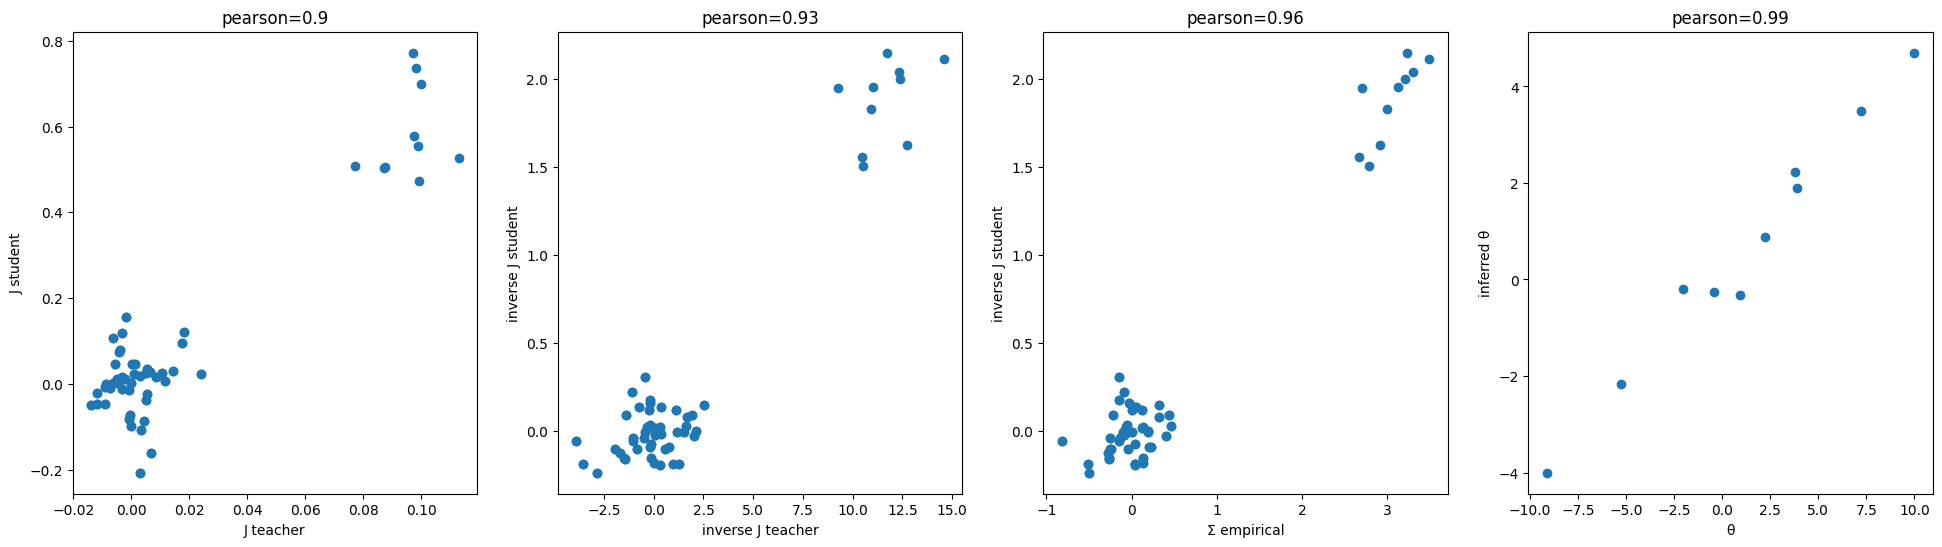

PyObject Text(0.5, 1.0, 'pearson=0.99')

In [67]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
rho_theta = cor(vec(θ), x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")

In [68]:
γ = vcat([0.001, 0.005], collect(0.1:0.1:1.5))

17-element Vector{Float64}:
 0.001
 0.005
 0.1
 0.2
 0.3
 0.4
 0.5
 0.6
 0.7
 0.8
 0.9
 1.0
 1.1
 1.2
 1.3
 1.4
 1.5

In [74]:
lγ = map(x->de.log_likelihood(x_opt_gamma[1:end-1], data, x, 0.0, 0.00), γ)

17-element Vector{Float64}:
 1445.7708906173527
  262.9786024532528
    3.615139602230163
    1.7293989471373326
    2.4554484146260975
    3.4728238382854593
    4.473999516841807
    5.401112405408816
    6.246927700981821
    7.016089222133423
    7.715527328108543
    8.351944792396827
    8.931273495857193
    9.458684451337602
    9.93872414961543
   10.375450671873812
   10.772538896707232

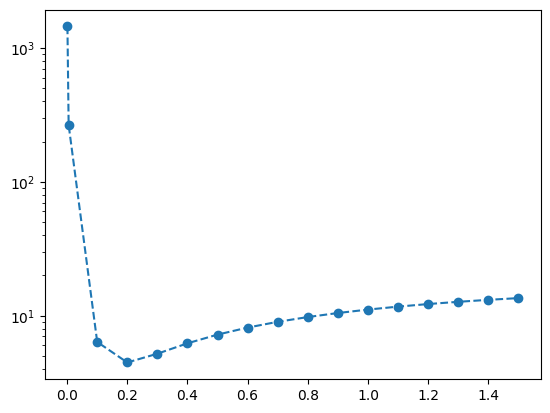

In [75]:
plot(γ, lγ .+ (minimum(lγ) + 1.0), linestyle="dashed", marker="o")
yscale(:log)

In [76]:
x_opt_gamma

66-element Vector{Float64}:
  0.5550022450219971
 -0.01222343147167813
  0.5064494043258326
  0.07848683922037787
  0.0169803651814611
  0.5077884039470444
  0.02512128699376338
  0.001155281506007372
  0.016320016083296578
  0.5033063071834857
  0.12119075664995546
 -0.04863914330602344
  0.09657988866789377
  ⋮
  0.7366194340334564
  1.2882459892444695
 -0.1822371587547475
  1.1402089064003154
 -0.2444097364585642
  2.1262964830514726
  2.602503897777179
  0.474190356399482
 -0.0503593274954732
 -1.2586472880759076
 -2.2763685964135063
  0.18678292053517

# using gamma from teacher

In [ ]:
de.npars(100)